# 구글 드라이브 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# 코드 경로 지정

In [ ]:
import os

# Create the directories if they don't exist
os.makedirs('/content/llm_dataset/test', exist_ok=True)
os.makedirs('/content/llm_dataset/train', exist_ok=True)

print("Directories '/content/llm_dataset/test' and '/content/llm_dataset/train' created.")

Directories '/content/llm_dataset/test' and '/content/llm_dataset/train' created.


# 데이터 압축 해제

In [ ]:
!unzip -q /content/drive/MyDrive/test_조립모듈/VL_중간조립모듈_zipped.zip -d /content/llm_dataset/test
!unzip -q /content/drive/MyDrive/test_조립모듈/VS_중간조립모듈_zipped.zip -d /content/llm_dataset/test
!unzip -q /content/drive/MyDrive/train_조립모듈/TL_중간조립모듈_zipped.zip -d /content/llm_dataset/train
!unzip -q /content/drive/MyDrive/train_조립모듈/TS_중간조립모듈_zipped.zip -d /content/llm_dataset/train

# 필요 라이브러리 설치

In [ ]:
!pip install ultralytics
!pip install grad-cam
!pip install optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=a6402b79425c706f2fb785a460d8dc5e860cba0123d3b16e771c4d6edb0ee5ea
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 27.5 MB/s eta 0:00:00


# YOLO 데이터셋 구조 재배치 및 라벨 변환
YOLO 프레임워크가 인식할 수 있도록 `images`와 `labels` 폴더 구조로 데이터를 정리하고, JSON을 TXT 라벨로 변환합니다.

In [ ]:
import os
import json
import glob
import shutil
import random
from tqdm import tqdm

base_dir = '/content/llm_dataset'

# 1. 고유한 Annotation_part_type 추출
print("1. 전체 데이터셋에서 고유한 부품 종류(Annotation_part_type)를 스캔합니다...")
part_types = set()
for split in ['train', 'test']:
    for j_path in glob.glob(os.path.join(base_dir, split, '*.json')):
        try:
            with open(j_path, 'r', encoding='utf-8-sig') as f:
                data = json.load(f)
            for ann in data.get('Annotation', []):
                ptype = ann.get('Annotation_part_type')
                if ptype:
                    part_types.add(ptype)
        except Exception:
            continue

part_type_list = sorted(list(part_types))
class_map = {ptype: i for i, ptype in enumerate(part_type_list)}

print(f"✅ 추출된 부품 클래스 매핑 (총 {len(class_map)}개):")
print(json.dumps(class_map, indent=2, ensure_ascii=False))

# 데이터 스플릿 준비
train_jsons = glob.glob(os.path.join(base_dir, 'train', '*.json'))
test_jsons = glob.glob(os.path.join(base_dir, 'test', '*.json'))

random.seed(42)
random.shuffle(train_jsons)

val_ratio = 0.2
val_size = int(len(train_jsons) * val_ratio)

split_dict = {
    'train': train_jsons[val_size:],
    'val': train_jsons[:val_size],
    'test': test_jsons
}

print("\n2. YOLO 라벨 변환 및 Train/Val/Test 분리 시작...")
for split_name, json_files in split_dict.items():
    images_dir = os.path.join(base_dir, 'images', split_name)
    labels_dir = os.path.join(base_dir, 'labels', split_name)

    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    for j_path in tqdm(json_files, desc=f"{split_name} 데이터 변환"):
        try:
            with open(j_path, 'r', encoding='utf-8-sig') as f:
                data = json.load(f)

            img_info = data.get('images', [{}])[0] if isinstance(data.get('images'), list) else data.get('images', {})

            if 'Img_resolution' in img_info and len(img_info['Img_resolution']) == 2:
                img_w = float(img_info['Img_resolution'][0])
                img_h = float(img_info['Img_resolution'][1])
            else:
                img_w = float(img_info.get('width', 0))
                img_h = float(img_info.get('height', 0))

            file_name = img_info.get('file_name', '')
            if not file_name:
                file_name = os.path.basename(j_path).replace('.json', '.jpg')
            base_name = os.path.splitext(file_name)[0]

            yolo_lines = []
            for ann in data.get('Annotation', []):
                ptype = ann.get('Annotation_part_type')
                if ptype not in class_map:
                    continue

                cid = class_map[ptype]
                bbox = ann.get('Annotation_bbox', [])

                if len(bbox) == 4 and img_w > 0 and img_h > 0:
                    x1, y1, x2, y2 = map(float, bbox)
                    width = (x2 - x1) / img_w
                    height = (y2 - y1) / img_h
                    x_center = (x1 + x2) / 2 / img_w
                    y_center = (y1 + y2) / 2 / img_h

                    if width > 0 and height > 0:
                        yolo_lines.append(f"{cid} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

            if yolo_lines:
                txt_path = os.path.join(labels_dir, f"{base_name}.txt")
                with open(txt_path, 'w') as f:
                    f.write('\n'.join(yolo_lines))

            # 이미지 파일 이동
            source_dir = os.path.dirname(j_path)
            img_src_path = os.path.join(source_dir, file_name)
            if not os.path.exists(img_src_path):
                img_src_path = os.path.join(source_dir, base_name + '.jpg')

            if os.path.exists(img_src_path):
                shutil.move(img_src_path, os.path.join(images_dir, os.path.basename(img_src_path)))

        except Exception:
            continue

# YAML 생성
data_yaml = f"""
path: /content/llm_dataset
train: images/train
val: images/val
test: images/test

nc: {len(part_type_list)}
names: {part_type_list}
"""
with open('custom_data.yaml', 'w', encoding='utf-8') as f:
    f.write(data_yaml.strip())

print("\n✅ 데이터 라벨 변환 및 YOLO 폴더 구조 세팅(Train/Val/Test)이 완료되었습니다! custom_data.yaml이 부품 종류(Annotation_part_type) 기준으로 업데이트되었습니다.")


1. 전체 데이터셋에서 고유한 부품 종류(Annotation_part_type)를 스캔합니다...
✅ 추출된 부품 클래스 매핑 (총 14개):
{
  "GPC형": 0,
  "GPL45형": 1,
  "GPL형": 2,
  "KCPC형": 3,
  "KCPLV형": 4,
  "KRPPL형": 5,
  "KRPT형": 6,
  "KRPUC형": 7,
  "KRPUL형": 8,
  "KRPY형": 9,
  "KRPZA형": 10,
  "KSPHL형": 11,
  "KSPL45형": 12,
  "KSPPL형": 13
}

2. YOLO 라벨 변환 및 Train/Val/Test 분리 시작...


test 데이터 변환: 100%|██████████| 21799/21799 [00:04<00:00, 4526.53it/s]


✅ 데이터 라벨 변환 및 YOLO 폴더 구조 세팅(Train/Val/Test)이 완료되었습니다! custom_data.yaml이 부품 종류(Annotation_part_type) 기준으로 업데이트되었습니다.


# 🛠️ Val 데이터 이미지 복구 및 재확인
이전 실행으로 인해 `images/train` 폴더에 모두 섞여버린 검증용(Val) 이미지들을 `labels/val` 폴더의 정보와 대조하여 다시 올바르게 이동시킵니다.

🛠️ 섞여있는 Val 이미지 복구 이동 중...
✅ 총 0장의 이미지를 'images/val' 폴더로 정상 분리했습니다!

📊 [복구 후] 데이터셋 분할 결과
------------------------------
Train 데이터: 139,414장 (71.1%)
  Val 데이터: 34,853장 (17.8%)
 Test 데이터: 21,799장 (11.1%)
------------------------------


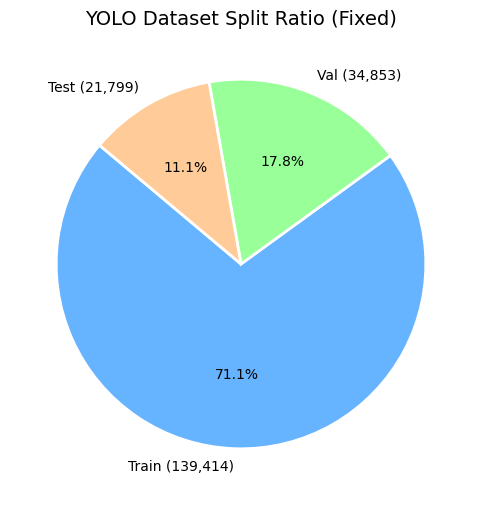

In [ ]:
import os
import shutil
import glob
import matplotlib.pyplot as plt

val_labels = glob.glob('/content/llm_dataset/labels/val/*.txt')
train_img_dir = '/content/llm_dataset/images/train'
val_img_dir = '/content/llm_dataset/images/val'

os.makedirs(val_img_dir, exist_ok=True)

print("🛠️ 섞여있는 Val 이미지 복구 이동 중...")
moved_count = 0
for label_path in val_labels:
    base_name = os.path.splitext(os.path.basename(label_path))[0]
    img_name = base_name + '.jpg'
    src_img = os.path.join(train_img_dir, img_name)
    dst_img = os.path.join(val_img_dir, img_name)

    if os.path.exists(src_img):
        shutil.move(src_img, dst_img)
        moved_count += 1

print(f"✅ 총 {moved_count}장의 이미지를 'images/val' 폴더로 정상 분리했습니다!\n")

# 다시 개수 세기 및 파이 차트 출력
base_dir = '/content/llm_dataset/images'
splits = ['train', 'val', 'test']
counts = {}

for split in splits:
    split_dir = os.path.join(base_dir, split)
    if os.path.exists(split_dir):
        counts[split] = len([f for f in os.listdir(split_dir) if f.endswith('.jpg')])
    else:
        counts[split] = 0

total = sum(counts.values())
print("📊 [복구 후] 데이터셋 분할 결과")
print("-" * 30)
for split, count in counts.items():
    ratio = (count / total) * 100 if total > 0 else 0
    print(f"{split.capitalize():>5} 데이터: {count:,}장 ({ratio:.1f}%)")
print("-" * 30)

if total > 0:
    plt.figure(figsize=(6, 6))
    plt.pie(counts.values(), labels=[f"{k.capitalize()} ({v:,})" for k, v in counts.items()],
            autopct='%1.1f%%', startangle=140,
            colors=['#66b3ff', '#99ff99', '#ffcc99'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    plt.title('YOLO Dataset Split Ratio (Fixed)', fontsize=14)
    plt.show()

# YOLO 분류 학습

In [ ]:
from ultralytics import YOLO

# ==========================================
# 부품 종류 분류(Part Type Detection) 모델 추가 학습 (70 에포크)
# ==========================================

# 1. 이전 30에포크 학습에서 가장 성능이 좋았던 가중치(best.pt)를 로드합니다.
model = YOLO()

# 2. 70에포크를 추가로 학습합니다. (총 100에포크 효과)
results = model.train(
    data='custom_data.yaml',
    epochs=70,               # 70에포크 추가 진행
    imgsz=640,
    batch=128,               # 👈 A100 GPU에 맞춰 넉넉한 배치 사이즈 설정 (OOM 발생 시 64로 조절)
    device=0,
    project='/content/drive/MyDrive/YOLO_ResNet/yolo_train_results_v12',
    name='part_type_detection_v12_70ep_more',  # 기존 결과와 섞이지 않도록 새 폴더명 지정
    task='detect',
    patience=10,             # 조기 종료 조건: 10에포크 동안 개선이 없으면 종료
    close_mosaic=10          # 마지막 10에포크에만 모자이크 끄기 (권장 설정)
)


Ultralytics 8.4.149 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=custom_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=part_type_detection_v12_70ep_more, nbs=64, nms=None, opse

KeyboardInterrupt: 

# ResNet + GradCAM

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 단일 ResNet 기반 4-Class 분류 모델 정의
# ResNet 모델 정의
class CustomResNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        # 사전 학습된 ResNet18 로드
        self.model = resnet18(weights=None)

        # 미세 단차(1~2mm 나사선 등) 학습을 위해 모든 파라미터 동결 해제 (Fine-tuning)
        for param in self.model.parameters():
            param.requires_grad = True

        # 4-Class(완전체결, 부분체결, 미체결, 오류체결) 분류를 위해 마지막 FC 레이어 수정
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

classification_model = CustomResNet(num_classes=4).to(device)
print("✅ 4-Class 분류를 위한 단일 ResNet-18 모델 (전체 Fine-tuning) 설정 완료!")

✅ 4-Class 분류를 위한 단일 ResNet-18 모델 (전체 Fine-tuning) 설정 완료!


# 4-Class 분류용 Custom Dataset 정의
JSON 어노테이션에서 `완전체결(0)`, `부분체결(1)`, `미체결(2)`, `오류체결(3)` 상태를 파싱하여 부품 이미지를 크롭하고 라벨을 반환하는 PyTorch Dataset 클래스를 생성합니다.

In [ ]:
import os
import json
import glob
import shutil
from PIL import Image
import torchvision.transforms.functional as TF
from tqdm import tqdm

def square_pad(image):
    w, h = image.size
    max_wh = max(w, h)
    hp = int((max_wh - w) / 2)
    vp = int((max_wh - h) / 2)
    padding = [hp, vp, max_wh - w - hp, max_wh - h - vp]
    return TF.pad(image, padding, 0, 'constant')

def create_resnet_dataset(json_dir, img_dirs, target_dir):
    class_names = ['0_Normal', '1_Partial', '2_Missing', '3_Error']

    # 이전 잘못된 데이터 초기화
    for c in class_names:
        dir_path = os.path.join(target_dir, c)
        if os.path.exists(dir_path):
            shutil.rmtree(dir_path)
        os.makedirs(dir_path, exist_ok=True)

    json_files = glob.glob(os.path.join(json_dir, '*.json'))
    valid_count = 0
    missing_img_count = 0

    for j_path in tqdm(json_files, desc=f"Processing {target_dir}"):
        try:
            with open(j_path, 'r', encoding='utf-8-sig') as f:
                data = json.load(f)

            img_info = data.get('images', [{}])[0] if isinstance(data.get('images'), list) else data.get('images', {})
            file_name = img_info.get('file_name', '')
            if not file_name:
                file_name = os.path.basename(j_path).replace('.json', '.jpg')

            base_name = os.path.splitext(file_name)[0]

            # YOLO 과정에서 분리된 train, val 폴더 모두에서 이미지 탐색
            img_path = None
            for d in img_dirs:
                p = os.path.join(d, file_name)
                if os.path.exists(p):
                    img_path = p
                    break

            if not img_path:
                missing_img_count += 1
                continue

            img = Image.open(img_path).convert('RGB')
            img_w, img_h = img.size

            for i, ann in enumerate(data.get('Annotation', [])):
                major = ann.get('Major_state', '')
                subclass = ann.get('Subclass_status', '')

                label = -1
                # '비정상' 안의 '정상' 텍스트 매칭 버그 수정
                if '부분' in subclass:
                    label = 1
                elif '미체결' in subclass:
                    label = 2
                elif '오류' in subclass or '오조립' in subclass:
                    label = 3
                elif major == '정상' or '완전' in subclass:
                    label = 0

                bbox = ann.get('Annotation_bbox', [])
                if label != -1 and len(bbox) == 4:
                    x1, y1, x2, y2 = map(float, bbox)
                    # Margin 20%
                    box_w, box_h = x2 - x1, y2 - y1
                    margin_x, margin_y = box_w * 0.2, box_h * 0.2

                    x1 = max(0, int(x1 - margin_x))
                    y1 = max(0, int(y1 - margin_y))
                    x2 = min(img_w, int(x2 + margin_x))
                    y2 = min(img_h, int(y2 + margin_y))

                    crop_img = img.crop((x1, y1, x2, y2))
                    padded_img = square_pad(crop_img)
                    final_img = padded_img.resize((224, 224), Image.Resampling.LANCZOS)

                    save_name = f"{base_name}_bbox{i}.jpg"
                    save_path = os.path.join(target_dir, class_names[label], save_name)
                    final_img.save(save_path, quality=95)
                    valid_count += 1
        except Exception:
            continue
    print(f"\n✅ 데이터셋 구축 완료! 총 {valid_count}장의 크롭 이미지가 저장되었습니다.")
    print(f"  - 이미지 누락(못 찾음): {missing_img_count}건")

print("🚀 ResNet용 학습 데이터셋 구축 시작...")
RESNET_TRAIN_DIR = '/content/resnet_dataset/train'
# JSON 원본 폴더와 이동된 이미지 폴더 매핑
json_source_dir = '/content/llm_dataset/train'
img_search_dirs = ['/content/llm_dataset/images/train', '/content/llm_dataset/images/val']

create_resnet_dataset(json_source_dir, img_search_dirs, RESNET_TRAIN_DIR)

🚀 ResNet용 학습 데이터셋 구축 시작...


Processing /content/resnet_dataset/train: 100%|██████████| 174267/174267 [1:24:07<00:00, 34.53it/s]


✅ 데이터셋 구축 완료! 총 543101장의 크롭 이미지가 저장되었습니다.
  - 이미지 누락(못 찾음): 0건


In [ ]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# 1. Transform 정의
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. 전체 데이터셋 로드 (ImageFolder 사용 - 하위 폴더명이 클래스명으로 자동 매핑됨)
RESNET_TRAIN_DIR = '/content/resnet_dataset/train'
full_dataset = datasets.ImageFolder(root=RESNET_TRAIN_DIR, transform=transform)

# 3. Train / Val 분할 (8:2 비율)
dataset_size = len(full_dataset)
val_size = int(dataset_size * 0.2)
train_size = dataset_size - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

# 4. DataLoader 생성
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"✅ Train/Val 데이터로더 준비 완료!")
print(f"  - 전체 데이터 수: {dataset_size}개")
print(f"  - Train 데이터: {len(train_dataset)}개")
print(f"  - Val 데이터: {len(val_dataset)}개")
print(f"  - 클래스 매핑: {full_dataset.class_to_idx}")

✅ Train/Val 데이터로더 준비 완료!
  - 전체 데이터 수: 543101개
  - Train 데이터: 434481개
  - Val 데이터: 108620개
  - 클래스 매핑: {'0_Normal': 0, '1_Partial': 1, '2_Missing': 2, '3_Error': 3}


# ResNet 학습

In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================
# 3. 모델 학습 루프 (Training Loop) + Early Stopping (Val Loss 기준)
# ==========================================
# 이전 셀에서 정의한 classification_model을 가져옵니다.
model = classification_model.to(device)

# ✨ Label Smoothing 적용 (과적합 방지 및 극단적 예측 완화, 0.1은 일반적인 권장값)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 50      # 에포크 수
patience = 5         # 5 에포크 동안 Val Loss 개선이 없으면 조기 종료
best_loss = float('inf')
patience_counter = 0
save_path = '/content/drive/MyDrive/YOLO_ResNet/best_classification_resnet_finetuned.pth'

print(f"🚀 단일 ResNet 학습 시작 (총 {num_epochs} 에포크, Early Stopping Patience: {patience})...")

for epoch in range(num_epochs):
    # ---------------- Train Phase ----------------
    model.train()
    train_loss = 0.0

    # ✨ tqdm을 사용하여 프로그레스 바 적용
    pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] [Train]")

    for batch in pbar:
        # 기존 샴 데이터로더(3개 반환)와 일반 데이터로더(2개 반환) 호환
        if len(batch) == 3:
            _, inputs, labels = batch
        else:
            inputs, labels = batch

        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # 단일 ResNet 추론
        outputs = model(inputs)

        # Loss 계산 및 역전파
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(train_loader)

    # ---------------- Validation Phase ----------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] [Val]")
        for batch in val_pbar:
            if len(batch) == 3:
                _, inputs, labels = batch
            else:
                inputs, labels = batch

            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    print(f"🏁 Epoch [{epoch+1}/{num_epochs}] 완료 - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # ---------------- Early Stopping & Save ----------------
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), save_path)
        print(f"🌟 Val Loss 최고 성능 갱신! 모델 가중치가 '{save_path}'에 저장되었습니다.")
    else:
        patience_counter += 1
        print(f"⚠️ Val Loss 개선 없음 (Patience: {patience_counter}/{patience})")

        if patience_counter >= patience:
            print(f"🛑 Early Stopping 발동! {epoch+1} 에포크에서 학습을 조기 종료합니다.")
            break

print("✅ 학습 과정이 모두 완료되었습니다!")

🚀 단일 ResNet 학습 시작 (총 50 에포크, Early Stopping Patience: 5)...


Epoch [1/50] [Train]:   0%|          | 9/3395 [00:03<23:49,  2.37it/s, Loss=1.1931]


KeyboardInterrupt: 

### 1. 테스트 데이터셋 구축 (ResNet 크롭용)
기존에 정의한 `create_resnet_dataset` 함수를 재활용하여 `/content/llm_dataset/test` 영역의 이미지들을 크롭하고 분류합니다.

In [ ]:
import os
import json
import glob
import shutil
import traceback
from PIL import Image
import torchvision.transforms.functional as TF
from tqdm import tqdm

def square_pad(image):
    w, h = image.size
    max_wh = max(w, h)
    hp = int((max_wh - w) / 2)
    vp = int((max_wh - h) / 2)
    padding = [hp, vp, max_wh - w - hp, max_wh - h - vp]
    return TF.pad(image, padding, 0, 'constant')

RESNET_TEST_DIR = '/content/resnet_dataset/test'
json_test_source_dir = '/content/llm_dataset/test'
img_test_search_dirs = [
    '/content/llm_dataset/images/test',
    '/content/llm_dataset/images/train',
    '/content/llm_dataset/images/val'
]

class_names = ['0_Normal', '1_Partial', '2_Missing', '3_Error']
for c in class_names:
    dir_path = os.path.join(RESNET_TEST_DIR, c)
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
    os.makedirs(dir_path, exist_ok=True)

print("🚀 ResNet용 테스트 데이터셋 재구축 시작...")
json_files = glob.glob(os.path.join(json_test_source_dir, '*.json'))
valid_count = 0
missing_img_count = 0
error_count = 0

for j_path in tqdm(json_files, desc="Cropping Test Set"):
    try:
        with open(j_path, 'r', encoding='utf-8-sig') as f:
            data = json.load(f)

        img_info = data.get('images', [{}])[0] if isinstance(data.get('images'), list) else data.get('images', {})
        file_name = img_info.get('file_name', '')
        if not file_name:
            file_name = os.path.basename(j_path).replace('.json', '.jpg')

        base_name = os.path.splitext(file_name)[0]

        # 파일 탐색
        img_path = None
        for d in img_test_search_dirs:
            p = os.path.join(d, file_name)
            if os.path.exists(p):
                img_path = p
                break

        if not img_path:
            missing_img_count += 1
            continue

        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size

        for i, ann in enumerate(data.get('Annotation', [])):
            major = ann.get('Major_state', '')
            subclass = ann.get('Subclass_status', '')

            label = -1
            if '부분' in subclass:
                label = 1
            elif '미체결' in subclass:
                label = 2
            elif '오류' in subclass or '오조립' in subclass:
                label = 3
            elif major == '정상' or '완전' in subclass:
                label = 0

            bbox = ann.get('Annotation_bbox', [])
            if label != -1 and len(bbox) == 4:
                x1, y1, x2, y2 = map(float, bbox)
                # Margin 20%
                box_w, box_h = x2 - x1, y2 - y1
                margin_x, margin_y = box_w * 0.2, box_h * 0.2

                x1 = max(0, int(x1 - margin_x))
                y1 = max(0, int(y1 - margin_y))
                x2 = min(img_w, int(x2 + margin_x))
                y2 = min(img_h, int(y2 + margin_y))

                crop_img = img.crop((x1, y1, x2, y2))
                padded_img = square_pad(crop_img)
                final_img = padded_img.resize((224, 224), Image.Resampling.LANCZOS)

                save_name = f"{base_name}_bbox{i}.jpg"
                save_path = os.path.join(RESNET_TEST_DIR, class_names[label], save_name)
                final_img.save(save_path, quality=95)
                valid_count += 1

    except Exception as e:
        error_count += 1
        if error_count == 1: # 첫 번째 에러만 상세 출력
            print(f"\n⚠️ 첫 번째 예외 발생 ({j_path}): {e}")
            traceback.print_exc()
        continue

print(f"\n✅ 테스트 데이터셋 구축 완료!")
print(f"  - 정상 생성: {valid_count}장")
print(f"  - 이미지 누락(못 찾음): {missing_img_count}건")
print(f"  - 파싱/크롭 오류 발생: {error_count}건")

🚀 ResNet용 테스트 데이터셋 재구축 시작...


Cropping Test Set: 100%|██████████| 21799/21799 [10:28<00:00, 34.68it/s]


✅ 테스트 데이터셋 구축 완료!
  - 정상 생성: 68144장
  - 이미지 누락(못 찾음): 0건
  - 파싱/크롭 오류 발생: 0건


### 2. 테스트 데이터 로더 정의 및 모델 성능 평가
학습 과정에서 저장한 최적의 모델 가중치(`best_classification_resnet_finetuned.pth`)를 불러와 Test 데이터셋에 대한 성능 지표를 출력합니다.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Transform 준비
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Test Dataset 클래스 (단일 이미지용)
class ResNetTestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['0_Normal', '1_Partial', '2_Missing', '3_Error']
        self.image_paths = []
        self.labels = []

        for i, cls_name in enumerate(self.classes):
            cls_dir = os.path.join(root_dir, cls_name)
            imgs = glob.glob(os.path.join(cls_dir, '*.jpg'))
            for img_path in imgs:
                self.image_paths.append(img_path)
                self.labels.append(i)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        target_img = Image.open(img_path).convert('RGB')

        if self.transform:
            target_img_t = self.transform(target_img)
        else:
            target_img_t = target_img

        return target_img_t, label, img_path

# 데이터로더 생성
RESNET_TEST_DIR = '/content/resnet_dataset/test'
test_dataset = ResNetTestDataset(
    root_dir=RESNET_TEST_DIR,
    transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

# 3. 최고 성능 모델 로드 및 평가
if 'classification_model' not in globals():
    print("⚠️ classification_model이 정의되지 않았습니다. 모델 정의 셀을 먼저 실행해주세요.")
else:
    model = classification_model.to(device)
    # 저장된 단일 ResNet 가중치 경로로 업데이트
    model.load_state_dict(torch.load('/content/drive/MyDrive/YOLO_ResNet/trained_weights/best_classification_resnet_finetuned.pth'))
    model.eval()

    all_preds = []
    all_labels = []

    print(f"\n🚀 테스트 데이터({len(test_dataset)}개) 평가 시작...")
    with torch.no_grad():
        for target_imgs, labels, _ in tqdm(test_loader, desc="Testing"):
            target_imgs = target_imgs.to(device)
            outputs = model(target_imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    if len(all_labels) > 0:
        print("\n📊 Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))
    else:
        print("\n⚠️ 테스트 데이터가 존재하지 않습니다. 이전 셀(테스트 데이터셋 구축)이 정상적으로 실행되었는지 확인해주세요.")


🚀 테스트 데이터(68144개) 평가 시작...


Testing: 100%|██████████| 533/533 [00:35<00:00, 15.05it/s]



📊 Classification Report:
              precision    recall  f1-score   support

    0_Normal       0.96      0.97      0.96     15903
   1_Partial       1.00      0.99      0.99     18832
   2_Missing       1.00      1.00      1.00     17832
     3_Error       0.96      0.97      0.97     15577

    accuracy                           0.98     68144
   macro avg       0.98      0.98      0.98     68144
weighted avg       0.98      0.98      0.98     68144



### 3. 예측 결과 시각화 (Grad-CAM)
단일 ResNet 모델이 이미지를 보고 불량(또는 정상) 여부를 판단할 때, 이미지의 어느 영역을 집중적으로 참조했는지 **Grad-CAM(Gradient-weighted Class Activation Mapping)** 을 통해 시각화합니다.

🔍 단일 ResNet 예측 결과 및 Grad-CAM 시각화 (최대 5개 샘플)...


/tmp/ipykernel_1550/1186505544.py:76: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


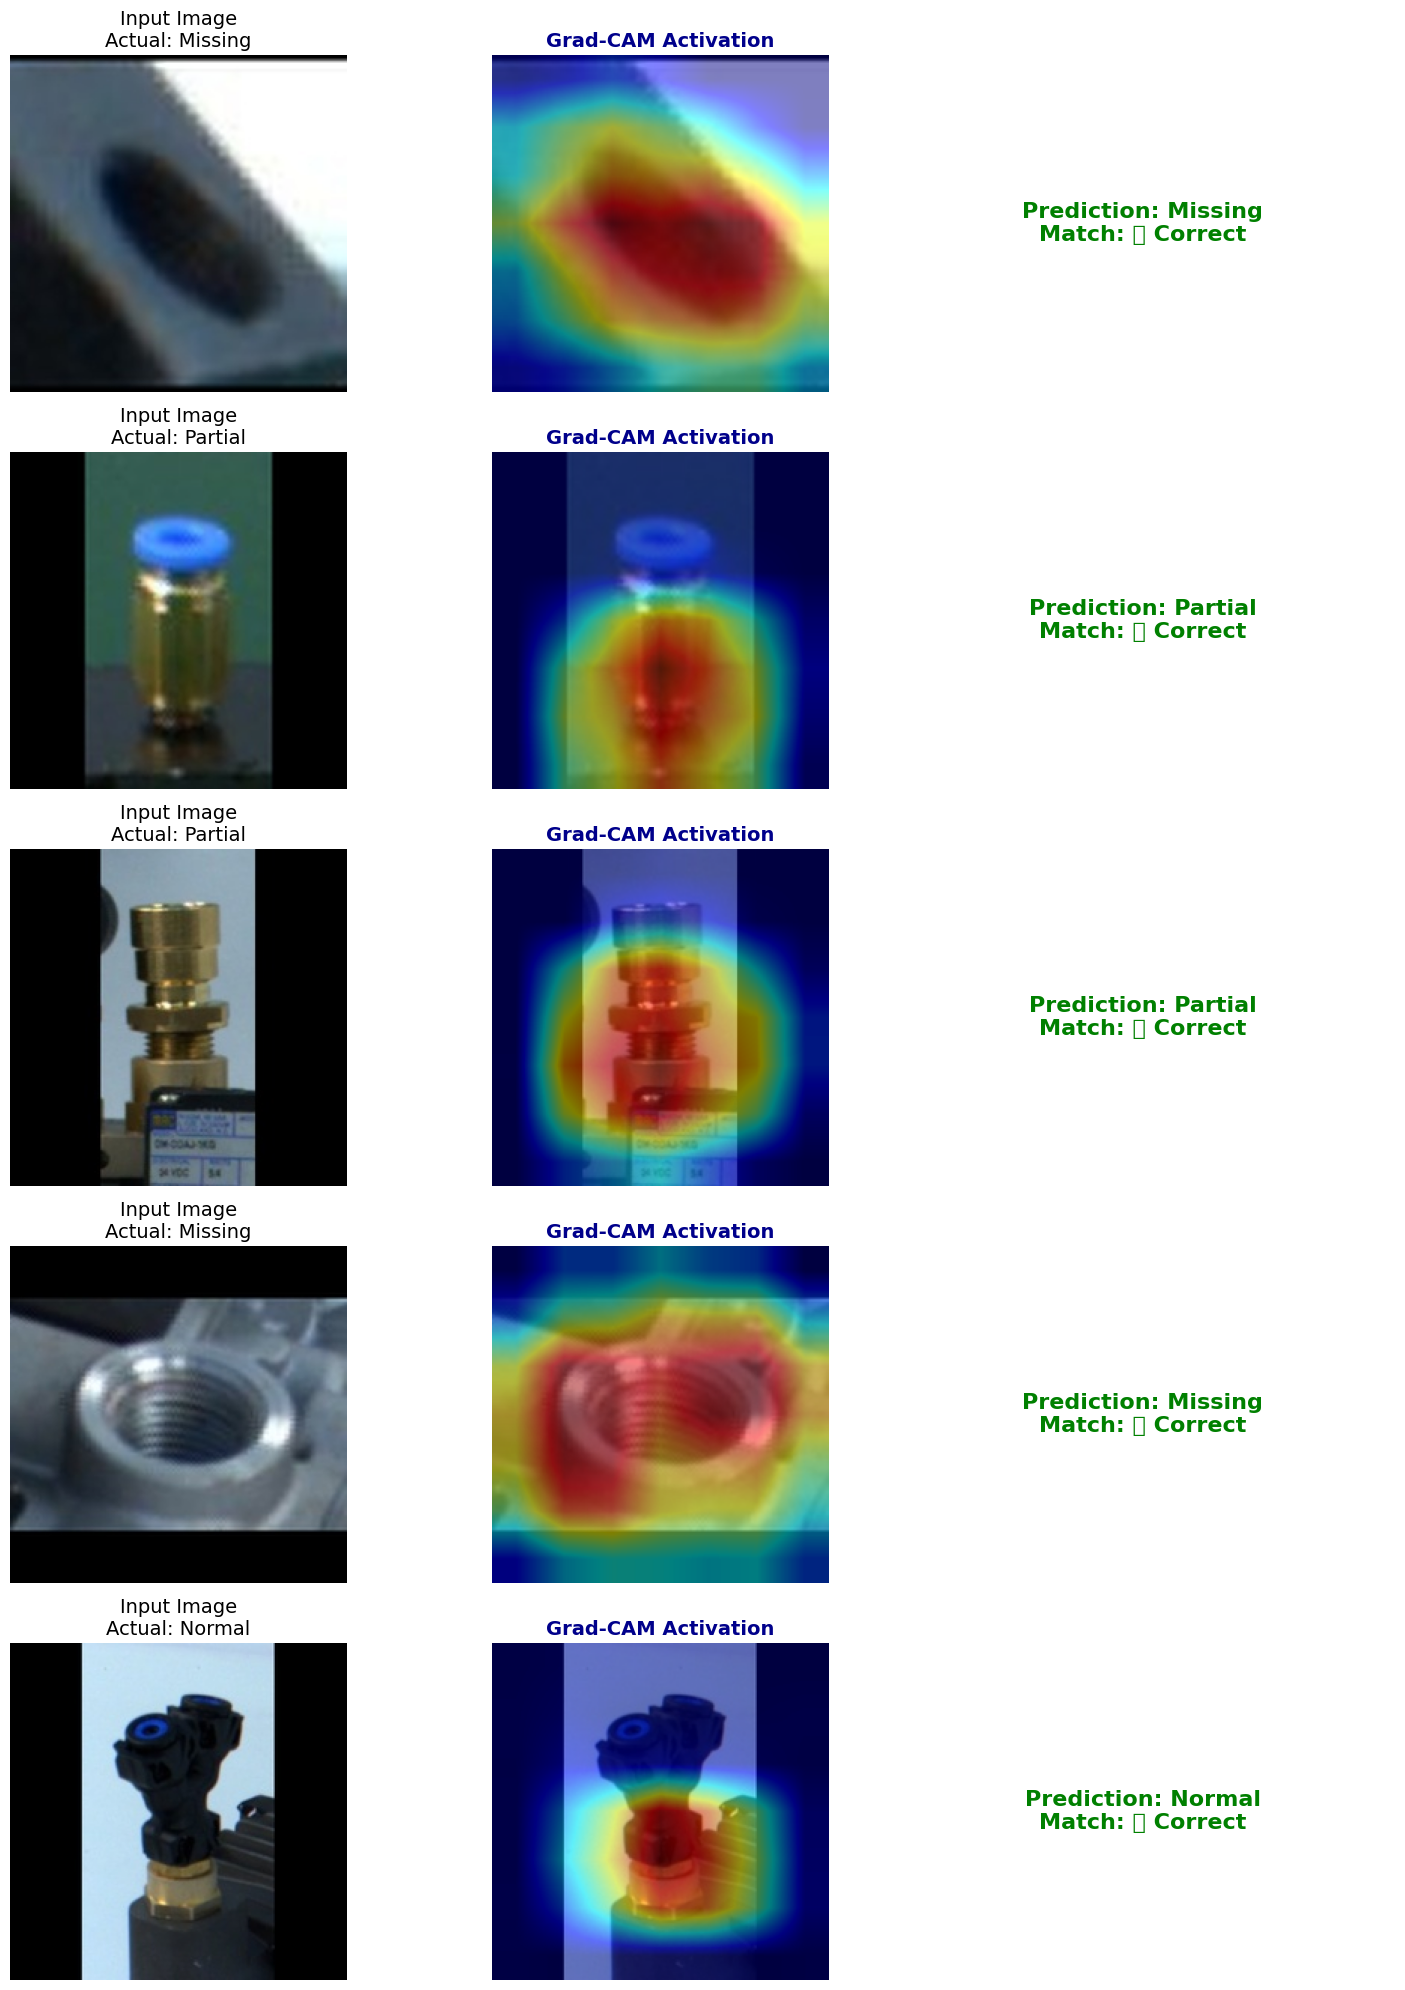

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img

def visualize_resnet_gradcam(model, dataset, num_samples=5):
    model.eval()

    if len(dataset) == 0:
        print("⚠️ 테스트 데이터가 없어 시각화를 수행할 수 없습니다.")
        return

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))
    class_names = dataset.classes

    # ResNet18의 마지막 합성곱 층(layer4의 마지막 블록)을 지정
    target_layers = [model.model.layer4[-1]]

    # GradCAM 인스턴스 생성
    cam = GradCAM(model=model, target_layers=target_layers)

    # 무작위 샘플 추출
    actual_samples = min(num_samples, len(dataset))
    indices = np.random.choice(len(dataset), actual_samples, replace=False)

    for i, idx in enumerate(indices):
        target_t, label, img_path = dataset[idx]
        input_tensor = target_t.unsqueeze(0).to(device)

        # 예측 수행
        with torch.no_grad():
            outputs = model(input_tensor)
            _, pred = torch.max(outputs, 1)
            pred_label = pred.item()

        # Grad-CAM은 역전파가 필요하므로 target 설정 후 CAM 계산
        targets = [ClassifierOutputTarget(pred_label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]

        # 텐서를 넘파이 이미지로 변환
        rgb_img = unnormalize(target_t)

        # 원본 이미지 위에 CAM 오버레이
        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        ax1, ax2, ax3 = axes[i] if actual_samples > 1 else axes

        # 원본 이미지
        ax1.imshow(rgb_img)
        ax1.set_title(f"Input Image\nActual: {class_names[label][2:]}", fontsize=14)
        ax1.axis('off')

        # Grad-CAM 결과
        ax2.imshow(cam_image)
        ax2.set_title("Grad-CAM Activation", fontsize=14, fontweight='bold', color='darkblue')
        ax2.axis('off')

        # 예측 결과 텍스트
        ax3.axis('off')
        color = 'green' if label == pred_label else 'red'
        text = f"Prediction: {class_names[pred_label][2:]}\n"
        text += f"Match: {'✅ Correct' if label == pred_label else '❌ Incorrect'}"
        ax3.text(0.5, 0.5, text, fontsize=16, ha='center', va='center', color=color, weight='bold')

    plt.tight_layout()
    plt.show()

print(f"🔍 단일 ResNet 예측 결과 및 Grad-CAM 시각화 (최대 {5}개 샘플)...")
visualize_resnet_gradcam(model, test_dataset, num_samples=5)